In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

print("All libraries loaded! Ready to analyze coffee ☕")

All libraries loaded! Ready to analyze coffee ☕


In [2]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

os.chdir(r'D:\Coffee Project')
df = pd.read_csv('df_arabica_clean.csv')
print(df.shape)
df.head()

(207, 41)


,Unnamed: 0,ID,Country of Origin,Farm Name,Lot Number,Mill,ICO Number,Company,Altitude,Region,...,Total Cup Points,Moisture Percentage,Category One Defects,Quakers,Color,Category Two Defects,Expiration,Certification Body,Certification Address,Certification Contact
0,0,0,Colombia,Finca El Paraiso,CQU2022015,Finca El Paraiso,NaN,Coffee Quality Union,1700-1930,"Piendamo,Cauca",...,89.33,11.8,0,0,green,3,"September 21st, 2023",Japan Coffee Exchange,"〒413-0002 静岡県熱海市伊豆山１１７３−５８ 1173-58 Izusan, Ata...",松澤 宏樹 Koju Matsuzawa - +81(0)9085642901
1,1,1,Taiwan,Royal Bean Geisha Estate,"The 2022 Pacific Rim Coffee Summit,T037",Royal Bean Geisha Estate,NaN,Taiwan Coffee Laboratory,1200,Chiayi,...,87.58,10.5,0,0,blue-green,0,"November 15th, 2023",Taiwan Coffee Laboratory 台灣咖啡研究室,"QAHWAH CO., LTD 4F, No. 225, Sec. 3, Beixin Rd...","Lin, Jen-An Neil 林仁安 - 886-289116612"
2,2,2,Laos,OKLAO coffee farms,"The 2022 Pacific Rim Coffee Summit,LA01",oklao coffee processing plant,NaN,Taiwan Coffee Laboratory,1300,Laos Borofen Plateau,...,87.42,10.4,0,0,yellowish,2,"November 15th, 2023",Taiwan Coffee Laboratory 台灣咖啡研究室,"QAHWAH CO., LTD 4F, No. 225, Sec. 3, Beixin Rd...","Lin, Jen-An Neil 林仁安 - 886-289116612"
3,3,3,Costa Rica,La Cumbre,CQU2022017,La Montana Tarrazu MIll,NaN,Coffee Quality Union,1900,"Los Santos,Tarrazu",...,87.17,11.8,0,0,green,0,"September 21st, 2023",Japan Coffee Exchange,"〒413-0002 静岡県熱海市伊豆山１１７３−５８ 1173-58 Izusan, Ata...",松澤 宏樹 Koju Matsuzawa - +81(0)9085642901
4,4,4,Colombia,Finca Santuario,CQU2023002,Finca Santuario,NaN,Coffee Quality Union,1850-2100,"Popayan,Cauca",...,87.08,11.6,0,2,yellow-green,2,"March 5th, 2024",Japan Coffee Exchange,"〒413-0002 静岡県熱海市伊豆山１１７３−５８ 1173-58 Izusan, Ata...",松澤 宏樹 Koju Matsuzawa - +81(0)9085642901


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 207 entries, 0 to 206
Data columns (total 41 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Unnamed: 0             207 non-null    int64  
 1   ID                     207 non-null    int64  
 2   Country of Origin      207 non-null    str    
 3   Farm Name              205 non-null    str    
 4   Lot Number             206 non-null    str    
 5   Mill                   204 non-null    str    
 6   ICO Number             75 non-null     str    
 7   Company                207 non-null    str    
 8   Altitude               206 non-null    str    
 9   Region                 205 non-null    str    
 10  Producer               206 non-null    str    
 11  Number of Bags         207 non-null    int64  
 12  Bag Weight             207 non-null    str    
 13  In-Country Partner     207 non-null    str    
 14  Harvest Year           207 non-null    str    
 15  Grading Date     

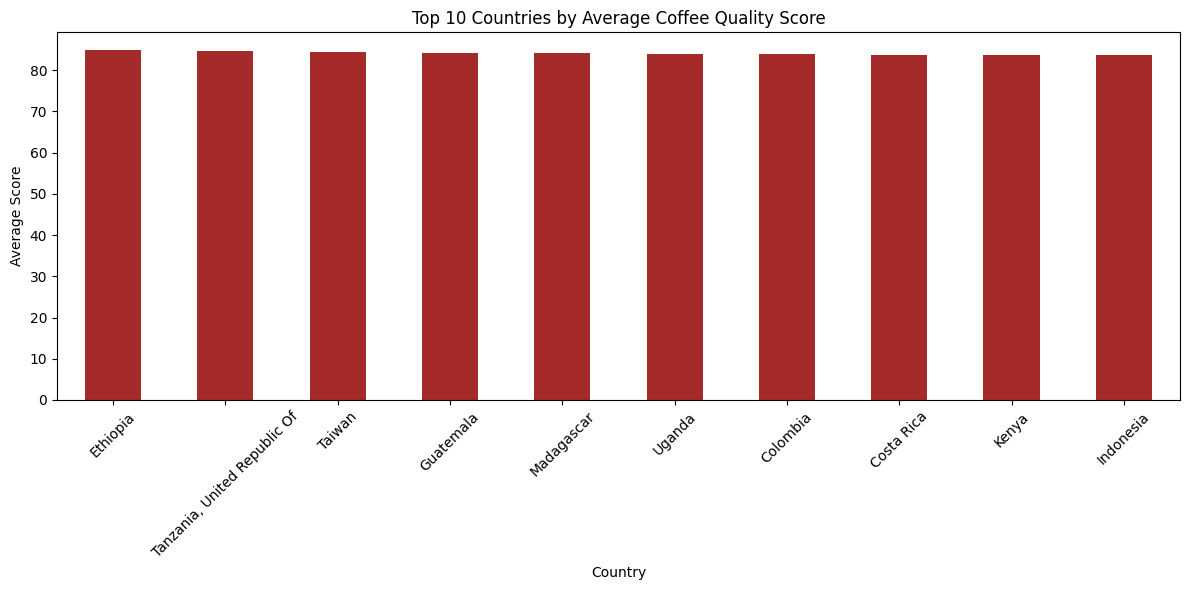

In [4]:
plt.figure(figsize=(12,6))
df.groupby('Country of Origin')['Total Cup Points'].mean().sort_values(ascending=False).head(10).plot(kind='bar', color='brown')
plt.title('Top 10 Countries by Average Coffee Quality Score')
plt.xlabel('Country')
plt.ylabel('Average Score')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Question 1: Which country produces the highest quality coffee?

### Finding:
Ethiopia produces the highest average coffee quality score (~85 points), 
followed closely by Tanzania and Taiwan. All top 10 countries 
score between 83-85 points showing strong competition globally.

### What this means:
Ethiopia leads coffee quality rankings which makes sense as it is 
the birthplace of coffee. Interestingly Taiwan appears in 3rd place 
showing that Asian countries can compete with traditional African 
coffee producers. The scores are very close between all 10 countries 
suggesting that geography alone does not determine quality,
farming and processing methods also play a big role.

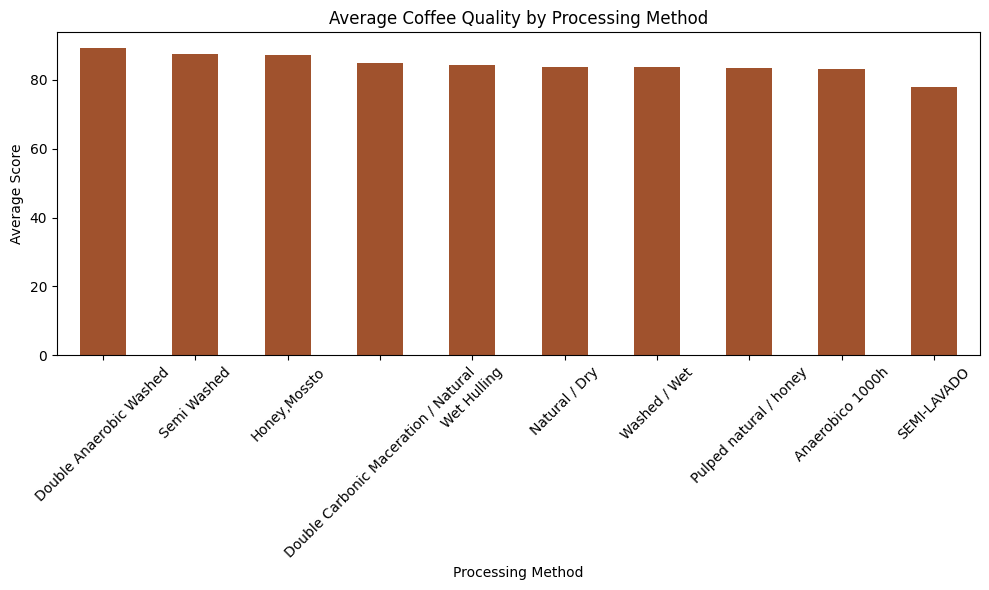

In [5]:
plt.figure(figsize=(10,6))
df.groupby('Processing Method')['Total Cup Points'].mean().sort_values(ascending=False).plot(kind='bar', color='sienna')
plt.title('Average Coffee Quality by Processing Method')
plt.xlabel('Processing Method')
plt.ylabel('Average Score')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Question 2: Does processing method affect coffee quality?

### Finding:
Double Anaerobic Washed processing method produces the highest 
average quality score (~90 points), significantly higher than 
the lowest method SEMI-LAVADO which scores around 79 points.

### What this means:
Yes, processing method clearly affects coffee quality. 
Double Anaerobic Washed is a modern and complex fermentation 
technique that enhances the flavor of coffee beans during 
processing. Traditional methods like Natural/Dry and Washed/Wet 
score in the middle range around 84 points. 
SEMI-LAVADO scores the lowest showing that not all 
processing methods produce equal quality results.
The difference of ~11 points between best and worst method 
is significant and shows that HOW coffee is processed 
matters just as much as WHERE it is grown.

c:\Users\HF STORE\AppData\Local\Programs\Python\Python314\Lib\site-packages\numpy\lib\_function_base_impl.py:3023: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
c:\Users\HF STORE\AppData\Local\Programs\Python\Python314\Lib\site-packages\numpy\lib\_function_base_impl.py:3024: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


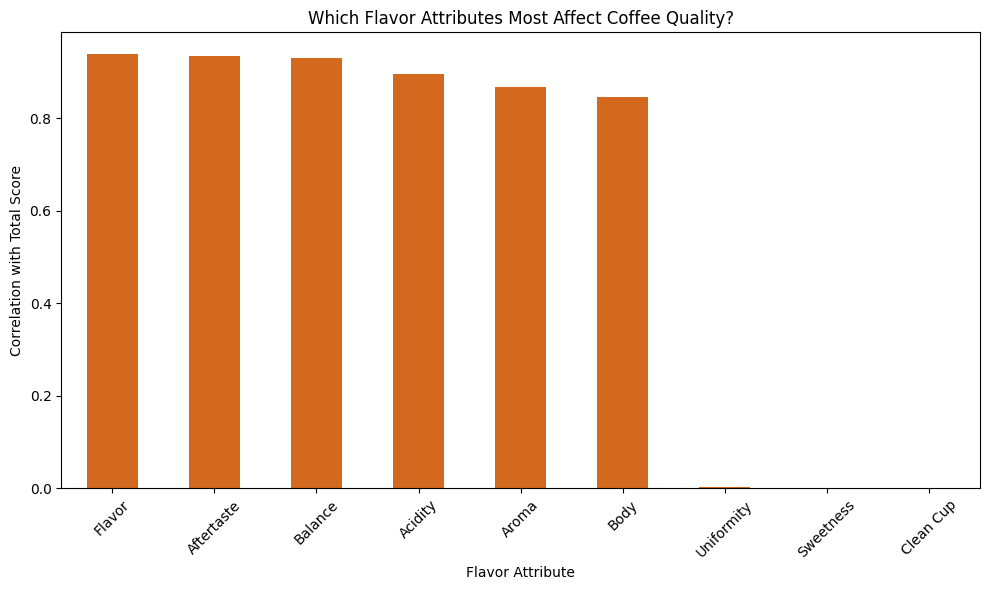

In [6]:
flavor_cols = ['Aroma', 'Flavor', 'Aftertaste', 'Acidity', 'Body', 'Balance', 'Sweetness', 'Clean Cup', 'Uniformity']

correlations = df[flavor_cols].corrwith(df['Total Cup Points']).sort_values(ascending=False)

plt.figure(figsize=(10,6))
correlations.plot(kind='bar', color='chocolate')
plt.title('Which Flavor Attributes Most Affect Coffee Quality?')
plt.xlabel('Flavor Attribute')
plt.ylabel('Correlation with Total Score')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Question 3: Which flavor attributes most predict coffee quality?

### Finding:
Flavor (0.95), Aftertaste (0.94) and Balance (0.93) are the 
strongest predictors of overall coffee quality score. 
Uniformity, Sweetness and Clean Cup have almost zero 
correlation with the total score.

### What this means:
When coffee experts rate a coffee, they are most influenced 
by how it tastes (Flavor), how long the taste lasts 
(Aftertaste) and how well all flavors work together (Balance).
Surprisingly, Sweetness and Cleanliness of the cup have 
almost no impact on the final score. This suggests that 
complexity and depth of flavor matter more than 
basic pleasantness in specialty coffee grading.

## Conclusion

This analysis of 207 coffee samples reveals that:
1. Ethiopia produces the highest quality coffee globally
2. Processing method significantly impacts quality,
   Double Anaerobic Washed being the best method
3. Flavor, Aftertaste and Balance are the key drivers 
   of overall coffee quality score

Dataset: Coffee Quality Institute (CQI) via Kaggle
Tools used: Python, Pandas, Matplotlib, Seaborn